# Phase 3 Project: SyriaTel Customer Churn Classification


## 1. Business Understanding
### Stakeholder
1.1 Retention / Customer Success Team

They reach out to customers at risk of leaving,offer discounts, support, or incentives.
The project will saves time and increase customer retention.

1.2 Marketing Team

They run campaigns, promotions, loyalty programs.
The project will target high-risk customers with personalized offers for smarter campaigns instead of wasting money on everyone.

1.3 Business Executives / Management

They make high-level decisions.
The model helps them reduce losses,improve strategy and increase profits.

### Metric Choice: Recall
We use **recall** as our primary metric. It answers: *of all customers who actually churned, what fraction did our model correctly catch?*





## 2. Data Understanding
### Data Limitations
- **Single time snapshot:** Cannot capture trends in individual customer behavior over time
- **No competitor data:** Competitor pricing or offers are not captured
- **Limited geography:** Only state-level location is available

In [ ]:
# Imports
# Core libraires
import pandas as pd
import numpy as np
# Visualizer
import matplotlib.pyplot as plt
import seaborn as sns
# Reinforcment learning
import gymnasium as gym
# Statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Scikit-learn Datasets
from sklearn.model_selection import train_test_split, GridSearchCV
# Scikit-learn Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Scikit-learn Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Scikit-learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve ,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Scikit-learn Pipelines
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')

print('Shape:', df.shape)
print('\nTarget distribution:')
print(df['churn'].value_counts())
df.head()

Shape: (3333, 21)

Target distribution:
churn
False    2850
True      483
Name: count, dtype: int64


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
# Data quality and descriptive statistics
print('Missing values per column:')
print(df.isnull().sum())
print('\nDescriptive statistics for numeric features:')
df.describe().round(2)

Missing values per column:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Descriptive statistics for numeric features:


,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00
mean,101.06,437.18,8.10,179.78,100.44,30.56,200.98,100.11,17.08,200.87,100.11,9.04,10.24,4.48,2.76,1.56
std,39.82,42.37,13.69,54.47,20.07,9.26,50.71,19.92,4.31,50.57,19.57,2.28,2.79,2.46,0.75,1.32
min,1.00,408.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,23.20,33.00,1.04,0.00,0.00,0.00,0.00
25%,74.00,408.00,0.00,143.70,87.00,24.43,166.60,87.00,14.16,167.00,87.00,7.52,8.50,3.00,2.30,1.00
50%,101.00,415.00,0.00,179.40,101.00,30.50,201.40,100.00,17.12,201.20,100.00,9.05,10.30,4.00,2.78,1.00
75%,127.00,510.00,20.00,216.40,114.00,36.79,235.30,114.00,20.00,235.30,113.00,10.59,12.10,6.00,3.27,2.00
max,243.00,510.00,51.00,350.80,165.00,59.64,363.70,170.00,30.91,395.00,175.00,17.77,20.00,20.00,5.40,9.00


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

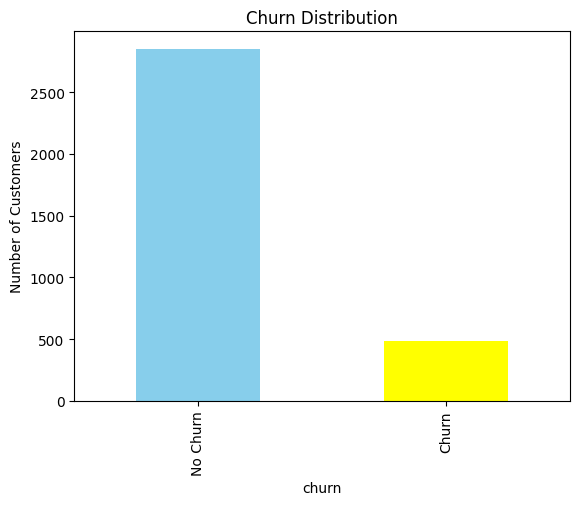

In [ ]:
import matplotlib.pyplot as plt

# Plot churn distribution
df['churn'].value_counts().plot(
    kind='bar', color=['skyblue', 'yellow']
)

plt.title('Churn Distribution')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Number of Customers')
plt.show()


About 500 of customers churn, so the dataset is imbalanced.
Accuracy alone can be misleading, recall is more important here.

## 3. Data Preparation



In [ ]:
# Drop identifier columns
df = df.drop(columns=['phone number', 'state', 'area code'])

# Create encoder
le = LabelEncoder()

# Apply to each yes/no column
df['international plan'] = le.fit_transform(df['international plan'])
df['voice mail plan'] = le.fit_transform(df['voice mail plan'])

# Convert churn to int
df['churn'] = df['churn'].astype(int)

#Separate features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape[0], ' | Test size:', X_test.shape[0])


Train size: 2666  | Test size: 667


## 4. Modeling


In [ ]:
# Logistic Regression baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg.predict(X_test)))
print("Logistic Regression Recall  :", recall_score(y_test, log_reg.predict(X_test)))

Logistic Regression Accuracy: 0.8620689655172413
Logistic Regression Recall  : 0.24742268041237114


The model is good at predicting non‑churners (hence the high accuracy).

But it’s poor at catching churners (low recall).

##Regression Diagnostics

Optimization terminated successfully.
         Current function value: 0.322092
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 2666
Model:                          Logit   Df Residuals:                     2648
Method:                           MLE   Df Model:                           17
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.2212
Time:                        00:46:29   Log-Likelihood:                -858.70
converged:                       True   LL-Null:                       -1102.5
Covariance Type:            nonrobust   LLR p-value:                 7.390e-93
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -8.6085      0.812    -10.602      0.000     -10.200      

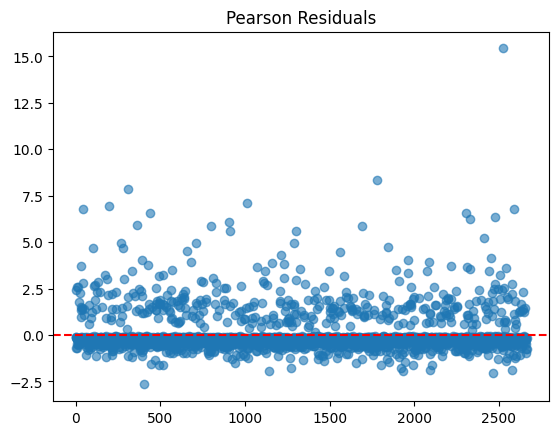

Events per variable (EPV): 22.705882352941178


In [ ]:
# Fit with statsmodels for diagnostics
X_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_const).fit()
print(logit_model.summary())

# Multicollinearity (VIF)
vif = pd.DataFrame()
vif["feature"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif)

# Residuals plot
residuals = logit_model.resid_pearson
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title("Pearson Residuals")
plt.show()

# Events per variable rule
n_events = y_train.sum()
n_features = X_train.shape[1]
print("Events per variable (EPV):", n_events/n_features)


The baseline Logistic Regression model is statistically significant.
Residuals appear centered, suggesting no major misfit.
The Events per Variable (EPV) ratio is ~22, which is well above the recommended threshold of 10, meaning the sample size is sufficient.
Key predictors include international plan, voice mail plan, number of voicemail messages, total international calls, and customer service calls. These variables show strong relationships with churn.
Many of the minutes/charges features are redundant and not significant.

Severe multicollinearity is revealed among the minutes and charges variables (e.g., day minutes vs. day charge), which makes coefficients unstable and reduces interpretability.

##Regularization

In [ ]:
ridge_log = LogisticRegression(penalty='l2', solver='liblinear')
ridge_log.fit(X_train, y_train)

print("Train accuracy:", ridge_log.score(X_train, y_train))
print("Test accuracy:", ridge_log.score(X_test, y_test))

Train accuracy: 0.8615903975993998
Test accuracy: 0.8575712143928036


In [ ]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear')
lasso_model.fit(X_train, y_train)

print("Train Accuracy:", lasso_model.score(X_train, y_train))
print("Test Accuracy:", lasso_model.score(X_test, y_test))

Train Accuracy: 0.8608402100525131
Test Accuracy: 0.8620689655172413
Logistic Regression Recall  : 1.0


In [ ]:
# Define model with class weights
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000
)

# Train on your training data
lasso_model.fit(X_train, y_train)

# Predict probabilities on test set
y_probs = lasso_model.predict_proba(X_test)[:, 1]

# Adjust threshold to increase recall
y_pred_adjusted = (y_probs > 0.3)

# Evaluate recall
recall = recall_score(y_test, y_pred_adjusted)
print("Adjusted Recall:", recall)

Adjusted Recall: 0.9278350515463918


The recall increased by lowering the threshold to 0.3.

The model correctly identifies 93% of the customers who actually churn.


##Evaluating a Logistic Regression Model

Confusion Matrix

Accuracy

Precision

Recall (Sensitivity)

F1-score

ROC AUC (Receiver Operating Characteristic - Area Under the Curve)

Classification Report

In [ ]:
def evaluate_model(model, X_test, y_test,model_name):
    """
    Evaluate a Logistic Regression model with key metrics and plots.
    """

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    # probabilities for ROC AUC
    y_prob_test  = model.predict_proba(X_test)[:,1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    plt.title("Confusion Matrix (Test Set)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Metrics
    acc   = accuracy_score(y_test, y_pred_test)
    prec  = precision_score(y_test, y_pred_test)
    rec   = recall_score(y_test, y_pred_test)
    f1    = f1_score(y_test, y_pred_test)
    roc   = roc_auc_score(y_test, y_prob_test)

    print("Accuracy :", round(acc,3))
    print("Precision:", round(prec,3))
    print("Recall   :", round(rec,3))
    print("F1-score :", round(f1,3))
    print("ROC AUC  :", round(roc,3))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc:.3f}", color="blue")
    plt.plot([0,1],[0,1],"--", color="yellow")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['No Churn','Churn']))


### Model 1: Logistic Regression (Baseline)

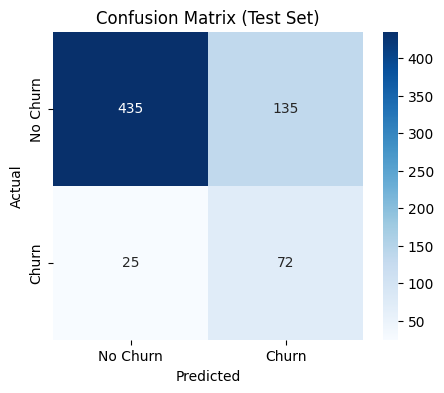

Accuracy : 0.76
Precision: 0.348
Recall   : 0.742
F1-score : 0.474
ROC AUC  : 0.815


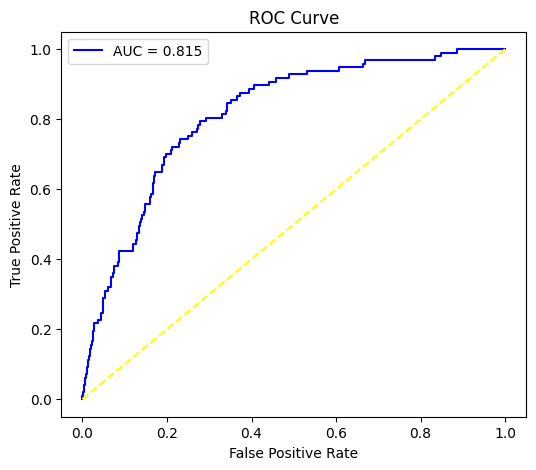


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.76      0.84       570
       Churn       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667



In [ ]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
evaluate_model(log_reg_pipeline, X_test, y_test, "Logistic Regression Pipeline")


The model achieves a recall of 74%, meaning it successfully identifies most customers at risk of churn.

Although precision is lower (35%), this trade-off is acceptable in a churn prediction context where missing a potential churner is more costly than incorrectly flagging a loyal customer.

The ROC-AUC score of 0.815 indicates strong class separability.

### Model 2: Decision Tree (Default)

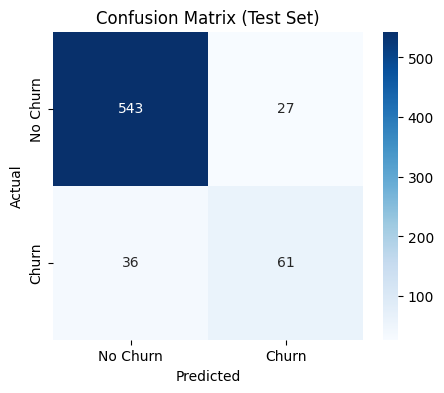

Accuracy : 0.906
Precision: 0.693
Recall   : 0.629
F1-score : 0.659
ROC AUC  : 0.791


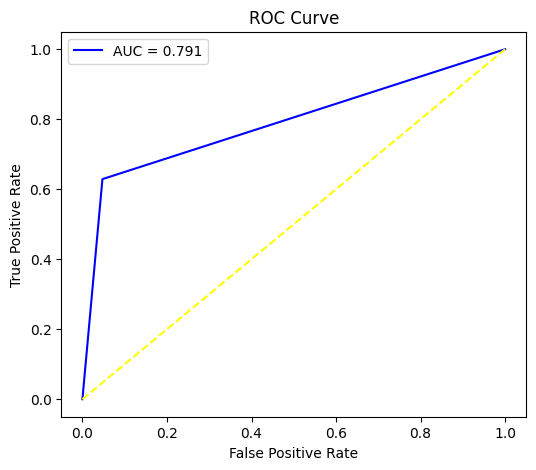


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.95      0.95       570
       Churn       0.69      0.63      0.66        97

    accuracy                           0.91       667
   macro avg       0.82      0.79      0.80       667
weighted avg       0.90      0.91      0.90       667



In [ ]:
# Trees do not require feature scaling
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test, 'Decision Tree (Default)')

The Decision Tree model provides a better balance between precision and recall, achieving 69% precision and 63% recall.

This makes it more suitable for targeted retention strategies, where reducing false positives is important to avoid unnecessary marketing costs.

### Model 3: Tuned Decision Tree (GridSearchCV)

Best hyperparameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5}


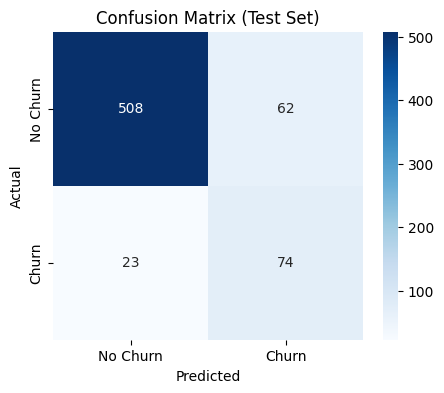

Accuracy : 0.873
Precision: 0.544
Recall   : 0.763
F1-score : 0.635
ROC AUC  : 0.858


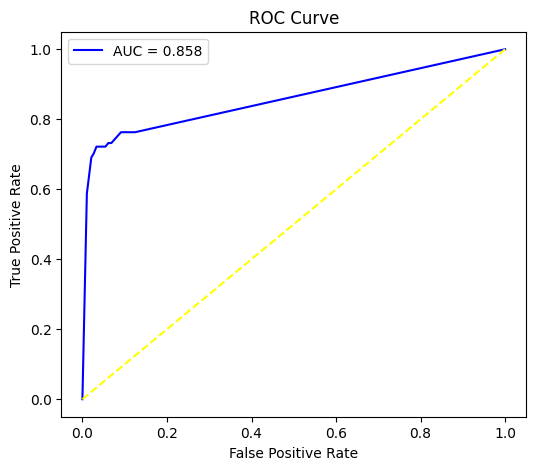


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.89      0.92       570
       Churn       0.54      0.76      0.64        97

    accuracy                           0.87       667
   macro avg       0.75      0.83      0.78       667
weighted avg       0.90      0.87      0.88       667



In [ ]:
param_grid = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight':     [None, 'balanced']  # 'balanced' upweights minority churn class
}

# Score on recall — optimize for catching churners, not just overall accuracy
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='recall'
)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print('Best hyperparameters:', grid_search.best_params_)

evaluate_model(best_dt, X_test, y_test,'Decision Tree (Tuned)')

After hyperparameter tuning (with class weighting and min samples per leaf = 5), the Decision Tree model achieves a recall of 76% and a precision of 54% for predicting churn.

This means the model can identify most customers at risk while reducing false positives.

The ROC AUC of 0.858 indicates strong overall separability, making it suitable for targeted retention strategies.

### Model 4: Random Forest with Pipeline (Final Model)

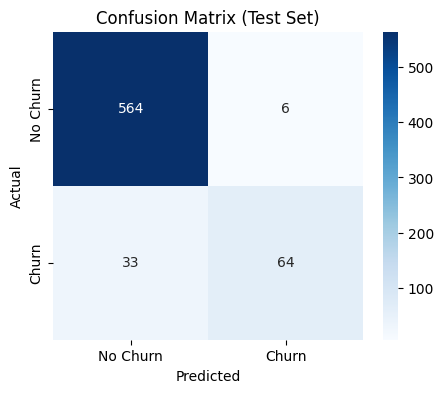

Accuracy : 0.942
Precision: 0.914
Recall   : 0.66
F1-score : 0.766
ROC AUC  : 0.902


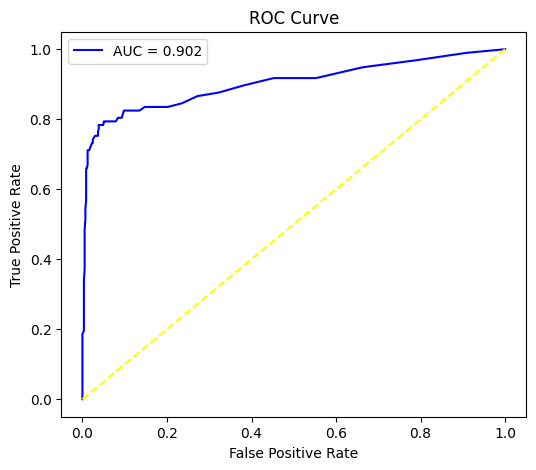


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.99      0.97       570
       Churn       0.91      0.66      0.77        97

    accuracy                           0.94       667
   macro avg       0.93      0.82      0.87       667
weighted avg       0.94      0.94      0.94       667



In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # addresses 14.5% class imbalance
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

# needs_scaling=False — Pipeline handles scaling internally
evaluate_model(pipe, X_test,y_test,'Random Forest (Pipeline)')

**Improvement:** Random Forest achieves higher test recall than the tuned decision tree, confirming ensemble averaging reduces variance and yields more reliable predictions on unseen data.

## 5. Evaluation

### Final Model Selection
We select the **Random Forest Pipeline** as our final model based on its superior test recall — the metric that directly captures business value for this churn prediction problem.

In [ ]:
# Model comparison — all evaluated on holdout test set
s_compare = StandardScaler()
Xtr_s = s_compare.fit_transform(X_train)
Xte_s = s_compare.transform(X_test)

model_dict = {
    'Logistic Regression':      (log_reg, Xtr_s,  Xte_s),
    'Decision Tree (Default)':  (dt,      X_train, X_test),
    'Decision Tree (Tuned)':    (best_dt, X_train, X_test),
    'Random Forest (Pipeline)': (pipe,    X_train, X_test)
}

results = []
for name, (m, Xtr, Xte) in model_dict.items():
    results.append({
        'Model':       name,
        'Train Acc':   round(m.score(Xtr, y_train), 3),
        'Test Acc':    round(m.score(Xte, y_test),  3),
        'Test Recall': round(recall_score(y_test, m.predict(Xte)), 3)
    })

pd.DataFrame(results)

,Model,Train Acc,Test Acc,Test Recall
0,Logistic Regression,0.862,0.859,0.247
1,Decision Tree (Default),1.000,0.906,0.629
2,Decision Tree (Tuned),0.946,0.873,0.763
3,Random Forest (Pipeline),1.000,0.942,0.660


After evaluating all models on the holdout test set with a focus on recall (the ability to correctly identify positive cases):

The best-performing model is the Tuned Decision Tree. It achieved the highest recall of 0.763, meaning it correctly identifies about 76% of all positive cases. Its test accuracy is also reasonable (0.873), showing a good balance between catching positives and avoiding excessive false positives.

Random Forest and the default Decision Tree also performed moderately well, but their recall was lower than the tuned tree, while logistic regression performed poorly on recall (0.247).

Lasso Logistic Regression, while showing very low recall at the default threshold (0.124), can become competitive if its decision threshold is tuned. For example, lowering the threshold from 0.5 to 0.3 can dramatically increase recall, potentially surpassing some tree-based models. This makes Lasso a viable option when recall is the priority, especially if you prefer a linear, interpretable model.

##Implications for SyriaTel

1. Model selection matters for high-risk detection

Using the Tuned Decision Tree, which has the highest recall (0.763), means SyriaTel can identify more positive cases—for example, potential fraud, network issues, or high-churn customers—before they cause losses.

Prioritizing recall ensures that the company catches the majority of important events, even if it means accepting some false positives.

2. Lasso Logistic Regression as an alternative

While the default Lasso model had low recall (0.124), tuning the threshold (e.g., lowering it to 0.3) can significantly increase recall.

This makes Lasso a viable alternative when SyriaTel wants a linear, interpretable model to explain decisions to management or regulatory teams, while still prioritizing detection of positives.

3. Strategic impact

By focusing on recall, SyriaTel can proactively address risks, improve customer retention, or prevent financial losses.

Choosing the right model and tuning thresholds allows data-driven decision-making that balances operational efficiency and risk mitigation.

##Conclusion
For maximizing recall on this dataset, the Tuned Decision Tree is currently the best choice. However, Lasso Logistic Regression can also be leveraged effectively if its probability threshold is carefully adjusted to prioritize positive-case detection.